# Repetition-Neighbor Lag-CRP

> Examine transitions between neighbors of different presentations of repeated items.

The repetition-neighbor CRP analysis examines transitions between items studied near different presentations of the same repeated item. For a repeated item at positions $i$ and $j$, the analysis tracks transitions from $j$'s neighbors to $i$'s neighborhood (j2i), from $i$'s neighbors to $j$'s neighborhood (i2j), or both.

These cross-occurrence neighbor transitions test whether recalling items near one presentation of a repeated item facilitates transitions to items near the other presentation.

## Workflow

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.repneighborcrp import (
    plot_rep_neighbor_crp,
    subject_rep_neighbor_crp,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
data_path = "../datasets/prepared/BroitmanKahana2024.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .35]
trial_query = "data['listLength'] > 0"
min_lag = 4
max_lag = 3
use_lag2 = True
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

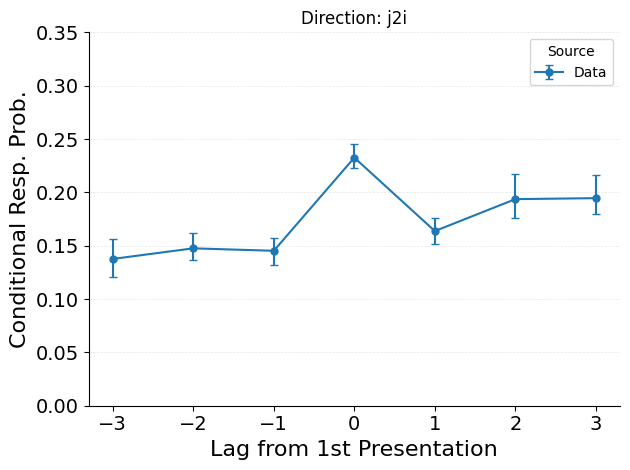

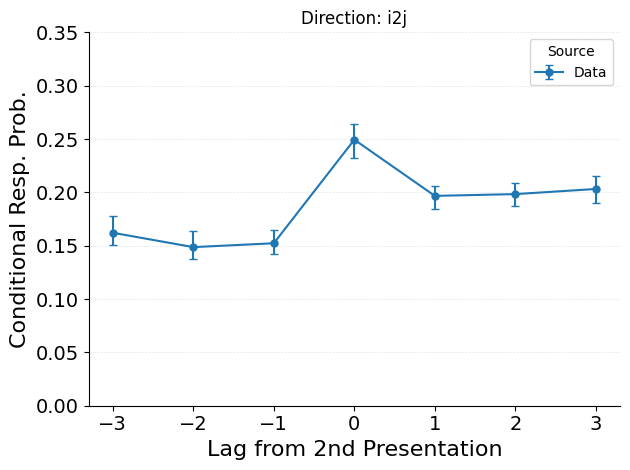

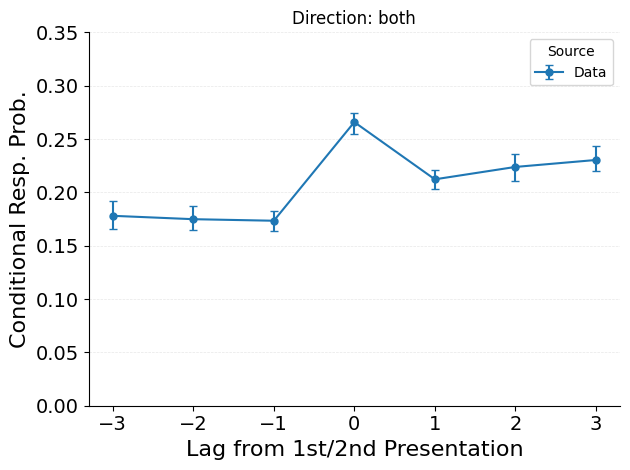

In [4]:
for direction in ["j2i", "i2j", "both"]:
    plot_rep_neighbor_crp(
        datasets=data,
        trial_masks=trial_mask,
        max_lag=max_lag,
        min_lag=min_lag,
        direction=direction,
        use_lag2=use_lag2,
        contrast_name="Source",
        labels=["Data"],
    )
    plt.title(f"Direction: {direction}")
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=direction)

## Interpretation

Plots show transition probabilities between neighbors of different presentations. Key patterns:

- **Cross-occurrence facilitation**: elevated transition probabilities between neighbors of different presentations indicate that recalling near one occurrence facilitates recall near the other.
- **Direction asymmetry**: j2i vs. i2j differences reveal whether the direction of cross-occurrence transitions matters.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits, or `None` for automatic scaling.
- `trial_query` — query selecting trials.
- `min_lag` — minimum absolute lag included in the analysis.
- `max_lag` — maximum absolute lag displayed.
- `use_lag2` — whether to include lag-2 neighbors in the analysis.